<a href="https://colab.research.google.com/github/sonjoy1s/OIBSIP/blob/main/Car_price_predictionTask3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder , OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

from sklearn.svm import SVR
from sklearn.cluster import KMeans
from sklearn.linear_model import Ridge
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR, LinearSVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor, AdaBoostRegressor,VotingRegressor, StackingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error


In [39]:
df = pd.read_csv("/content/car data.csv")

In [40]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [42]:
df.shape

(301, 9)

In [43]:
df['Owner'].nunique()

3

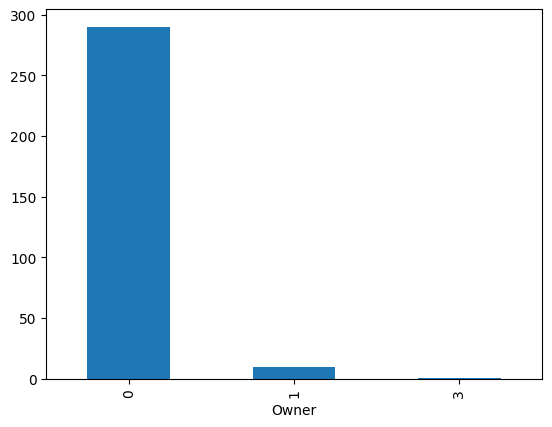

In [44]:
df['Owner'].value_counts().plot(kind='bar')
plt.show()

In [45]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,301.0,2013.627907,2.891554,2003.00,2012.0,2014.0,2016.0,2018.0
Selling_Price,301.0,4.661296,5.082812,0.10,0.9,3.6,6.0,35.0
Present_Price,301.0,7.628472,8.642584,0.32,1.2,6.4,9.9,92.6
Driven_kms,301.0,36947.205980,38886.883882,500.00,15000.0,32000.0,48767.0,500000.0
Owner,301.0,0.043189,0.247915,0.00,0.0,0.0,0.0,3.0


In [46]:
df.isna().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Driven_kms,0
Fuel_Type,0
Selling_type,0
Transmission,0
Owner,0


In [47]:
df.nunique()

,0
Car_Name,98
Year,16
Selling_Price,156
Present_Price,148
Driven_kms,206
Fuel_Type,3
Selling_type,2
Transmission,2
Owner,3


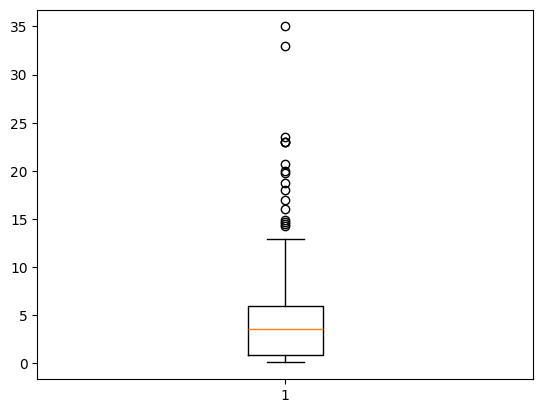

In [48]:
plt.boxplot(df['Selling_Price'])
plt.show()

In [49]:
Q1 = df["Selling_Price"].quantile(0.25)
Q3 = df["Selling_Price"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["Selling_Price"] < lower) | (df["Selling_Price"] > upper)]

print("Number of outliers:", len(outliers))

Number of outliers: 17


In [50]:
lower = df["Selling_Price"].quantile(0.01)
upper = df["Selling_Price"].quantile(0.99)

df["Selling_Price"] = df["Selling_Price"].clip(lower, upper)

In [51]:
scaling = StandardScaler()
df['Selling_Price'] = scaling.fit_transform(df[['Selling_Price']])

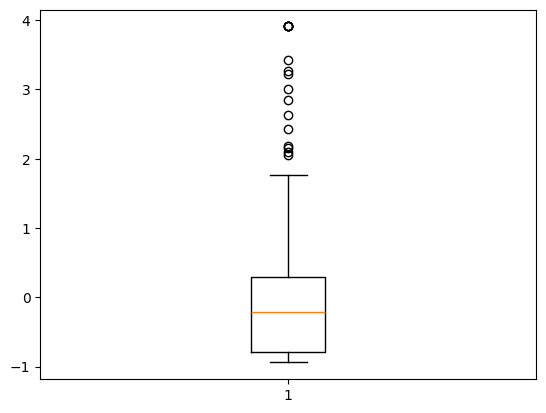

In [52]:
plt.boxplot(df['Selling_Price'])
plt.show()

In [54]:
X = df.drop(columns=['Selling_Price'],axis=1)
y = df['Selling_Price']

In [55]:
numerical_cols  = X.select_dtypes(include=np.number).columns

print(numerical_cols)

categorical_cols = X.select_dtypes(include=object).columns

print(categorical_cols)

Index(['Year', 'Present_Price', 'Driven_kms', 'Owner'], dtype='object')
Index(['Car_Name', 'Fuel_Type', 'Selling_type', 'Transmission'], dtype='object')


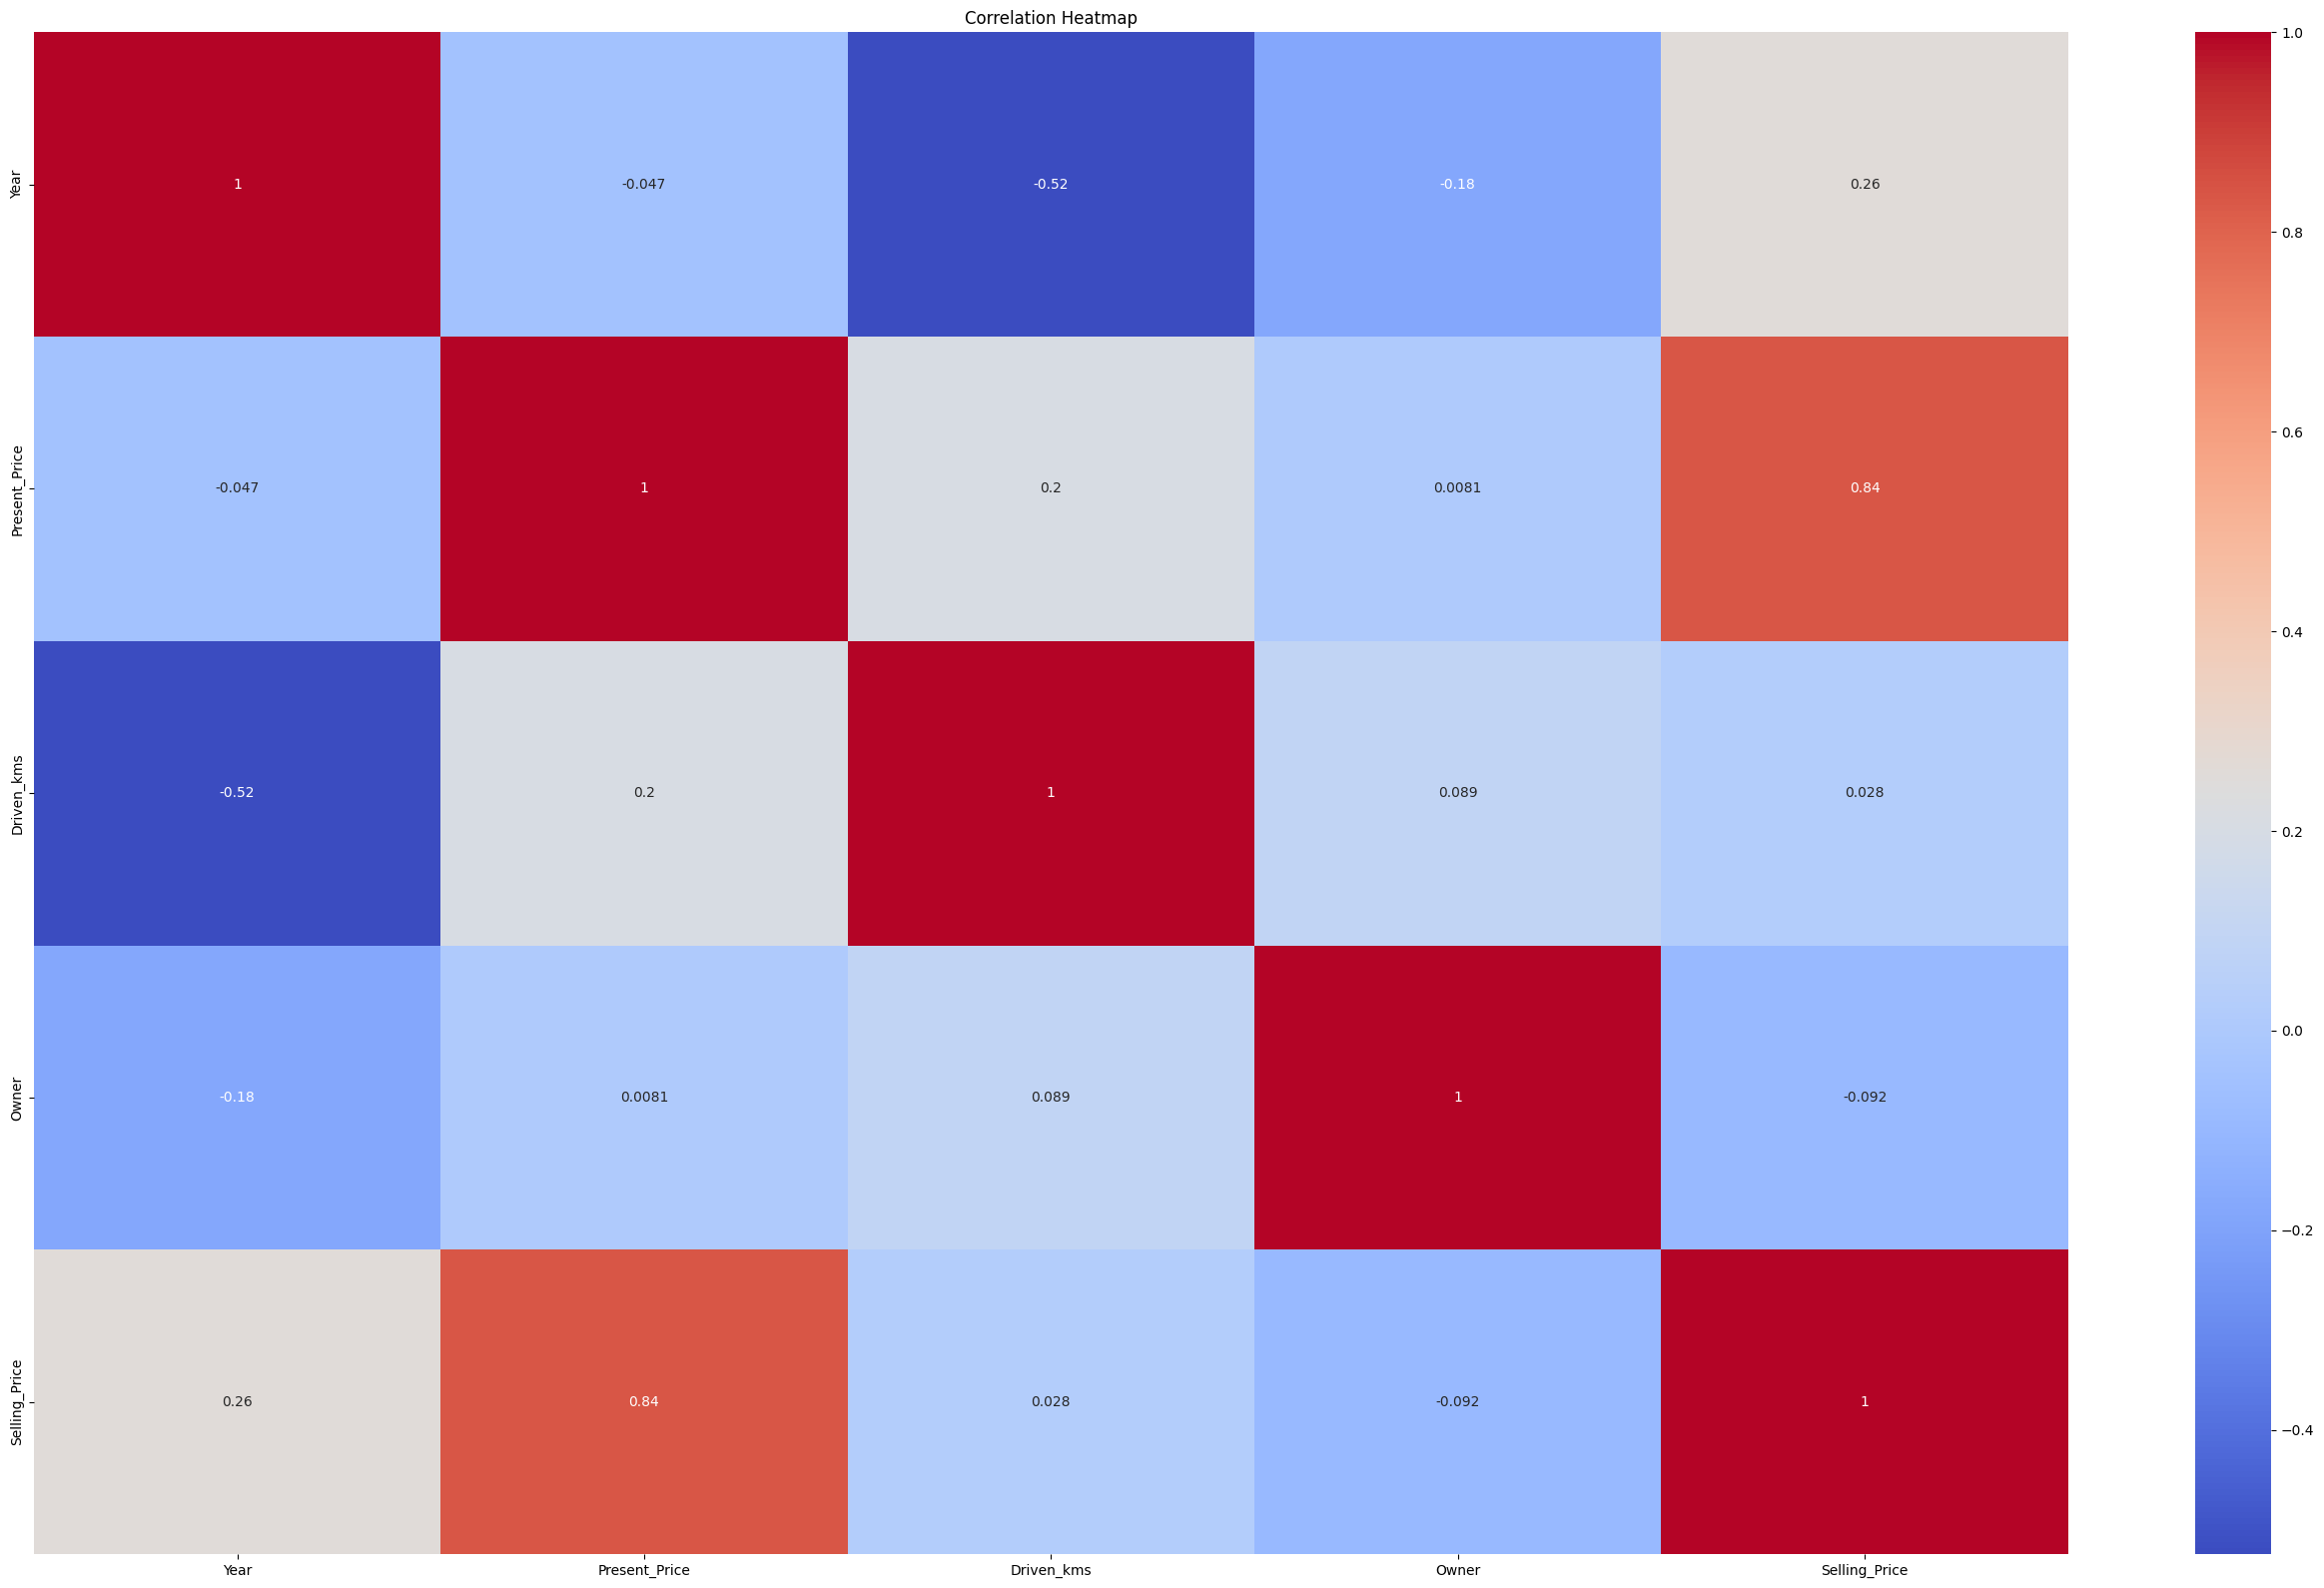

In [56]:
target_col ='Selling_Price'
plt.figure(figsize=(26,16))
corr_matrix = df[list(numerical_cols) + [target_col]].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [57]:
#numerical Pipeline
numerical_pipe = Pipeline(
    steps=[
        ('imputer',SimpleImputer(strategy='median')),
        ('scaler',StandardScaler())
    ]
)

In [58]:
categorical_pipe = Pipeline(
    steps=[
        ('imputer',SimpleImputer(strategy='most_frequent')),
        ('onehot',OneHotEncoder(handle_unknown='ignore'))
    ]
)

In [60]:
Combine_pipe = ColumnTransformer([
    ('num',numerical_pipe,numerical_cols),
    ('cat',categorical_pipe,categorical_cols)
]
)

In [61]:
X_train,X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state=42)

In [63]:
X_train.shape

(240, 8)

In [64]:
X_test.shape

(61, 8)

In [75]:
# Base Model Train
linear_reg = LinearRegression()
dt = DecisionTreeRegressor()
rf = RandomForestRegressor()
svr = SVR()
knn = KNeighborsRegressor()
gbr = GradientBoostingRegressor()
abr = AdaBoostRegressor()
linear_svr_model = LinearSVR()
kmeans = KMeans()
ridge = Ridge()

In [71]:
voting_reg = VotingRegressor(
    estimators=[
        ('linear_reg', linear_reg),
        ('dt', dt),
        ('rf', rf),
        ('gbr', gbr),
        ('abr', abr),
        ('knn', knn)
    ]
)

In [73]:
stacking_reg = StackingRegressor(
    estimators=[
        ('linear_reg', LinearRegression()),
        ('dt', DecisionTreeRegressor(random_state=42)),
        ('rf', RandomForestRegressor(random_state=42)),
        ('gbr', GradientBoostingRegressor(random_state=42)),
        ('abr', AdaBoostRegressor(random_state=42)),
        ('svr', SVR())
    ],
    final_estimator=Ridge()
)

In [76]:
model_to_train ={
    'LinearRegression':linear_reg,
    'DecisionTreeRegressor':dt,
    'RandomForestRegressor':rf,
    'SVR':svr,
    'KNeighborsRegressor':knn,
    'GradientBoostingRegressor':gbr,
    'AdaBoostRegressor':abr,
    'LinearSVR':linear_svr_model,
    'VotingRegressor':voting_reg,
    'StackingRegressor':stacking_reg,
    'KMeans':kmeans,
    'Ridge':Ridge()
}

In [77]:
results = []
for model_name, model in model_to_train.items():
  print(f"--- Training and Evaluating {model_name} ---")
  pipe = Pipeline(
      steps=[
          ('combine', Combine_pipe),
          ('model', model)
      ]
  )
  pipe.fit(X_train, y_train)
  y_pred = pipe.predict(X_test)

  mse = mean_squared_error(y_test, y_pred)
  r2 = r2_score(y_test, y_pred)
  mae = mean_absolute_error(y_test, y_pred)
  results.append({
      'Model':model_name,
      'MSE':mse,
      'R2':r2,
      'MAE':mae
  })
  print(f"MSE: {mse},R2: {r2},MAE : {mae}")

print("\n----All Model Results----")

for result in results:
  print(f"Model: {result['Model']},MSE: {result['MSE']},R2: {result['R2']},MAE: {result['MAE']}")

--- Training and Evaluating LinearRegression ---
MSE: 0.10750007607427063,R2: 0.8950695454063329,MAE : 0.23465425701701767
--- Training and Evaluating DecisionTreeRegressor ---
MSE: 0.05478708188057471,R2: 0.9465225177736863,MAE : 0.14540776889903462
--- Training and Evaluating RandomForestRegressor ---
MSE: 0.038524994334070035,R2: 0.9623958855070992,MAE : 0.12751892418527114
--- Training and Evaluating SVR ---
MSE: 0.03308509400963716,R2: 0.9677057535074959,MAE : 0.11572276940505345
--- Training and Evaluating KNeighborsRegressor ---
MSE: 0.06195826105975131,R2: 0.9395227544365539,MAE : 0.15781162931923953
--- Training and Evaluating GradientBoostingRegressor ---
MSE: 0.03531932175910586,R2: 0.9655249314841183,MAE : 0.12389004968169855
--- Training and Evaluating AdaBoostRegressor ---
MSE: 0.0676247082752741,R2: 0.9339917547947951,MAE : 0.18528996953551033
--- Training and Evaluating LinearSVR ---
MSE: 0.13396296782558711,R2: 0.8692392077662905,MAE : 0.23124796758636898
--- Training 

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


MSE: 0.038561946297898234,R2: 0.9623598168222739,MAE : 0.1279003886463496
--- Training and Evaluating StackingRegressor ---
MSE: 0.027265285417409094,R2: 0.9733864486616901,MAE : 0.12813014693941643
--- Training and Evaluating KMeans ---
MSE: 10.208428643077703,R2: -8.964412094602546,MAE : 2.7445694970562724
--- Training and Evaluating Ridge ---
MSE: 0.12572194107817375,R2: 0.8772832456358751,MAE : 0.23280438861446537

----All Model Results----
Model: LinearRegression,MSE: 0.10750007607427063,R2: 0.8950695454063329,MAE: 0.23465425701701767
Model: DecisionTreeRegressor,MSE: 0.05478708188057471,R2: 0.9465225177736863,MAE: 0.14540776889903462
Model: RandomForestRegressor,MSE: 0.038524994334070035,R2: 0.9623958855070992,MAE: 0.12751892418527114
Model: SVR,MSE: 0.03308509400963716,R2: 0.9677057535074959,MAE: 0.11572276940505345
Model: KNeighborsRegressor,MSE: 0.06195826105975131,R2: 0.9395227544365539,MAE: 0.15781162931923953
Model: GradientBoostingRegressor,MSE: 0.03531932175910586,R2: 0.9

In [81]:
best_r2 = -float('inf')
best_model_name = ''

for res in results:
    if res['R2'] > best_r2:
        best_r2 = res['R2']
        best_model_name = res['Model']

best_model_obj = model_to_train[best_model_name]

print(f"Best Model: {best_model_name}")
print(f"Best R² Score: {best_r2:.4f}")
print(f"Best Model Object: {best_model_obj}")

Best Model: StackingRegressor
Best MSE : inf
Best R² Score: 0.9734
Best Model Object: StackingRegressor(estimators=[('linear_reg', LinearRegression()),
                              ('dt', DecisionTreeRegressor(random_state=42)),
                              ('rf', RandomForestRegressor(random_state=42)),
                              ('gbr',
                               GradientBoostingRegressor(random_state=42)),
                              ('abr', AdaBoostRegressor(random_state=42)),
                              ('svr', SVR())],
                  final_estimator=Ridge())


In [82]:
final_pipe = Pipeline([
    ('combine', Combine_pipe),
    ('model', best_model_obj)
])

final_pipe.fit(X_train, y_train)

y_final_pred = final_pipe.predict(X_test)

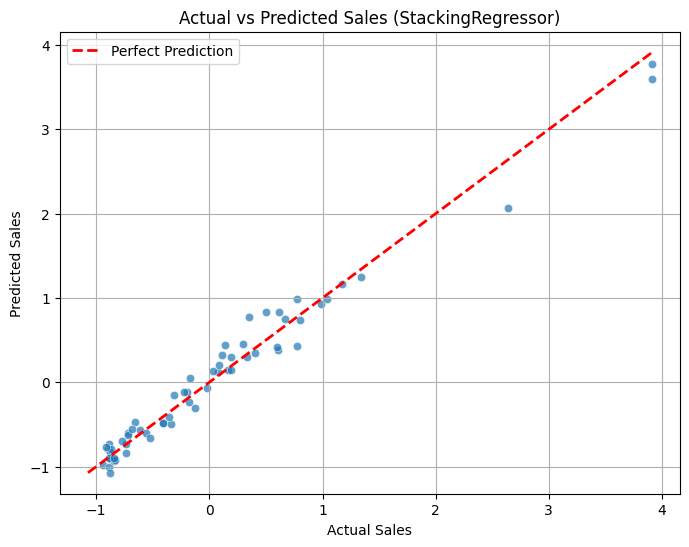

In [83]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=y_test,
    y=y_final_pred,
    alpha=0.7
)

min_val = min(min(y_test), min(y_final_pred))
max_val = max(max(y_test), max(y_final_pred))

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    'r--',
    linewidth=2,
    label='Perfect Prediction'
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title(f"Actual vs Predicted Sales ({best_model_name})")

plt.legend()
plt.grid(True)

plt.show()

In [86]:
model_reg = stacking_reg
pipe_reg = Pipeline(
    steps=[
        ('combine', Combine_pipe),
        ('model', model_reg)
    ]
)
pipe_reg.fit(X_train, y_train)
y_pred_lr = pipe_reg.predict(X_test)
print(f"MSE : {mean_squared_error(y_test, y_pred_lr)}")
print(f"R2 : {r2_score(y_test, y_pred_lr)}")

MSE : 0.027265285417409094
R2 : 0.9733864486616901
